In [248]:
import numpy as np
import matplotlib.pyplot as plt

In [249]:
num_samples = 100

mean, std_deviation = 0, 1
gaussian_noise = np.random.normal(mean, std_deviation, num_samples)

X = np.linspace(0, 10, 100)
y = 2 * X + 5 + gaussian_noise


In [250]:
print(X.shape)
print(y.shape)

(100,)
(100,)


Text(0.5, 1.0, 'y = 2x + 5 + e')

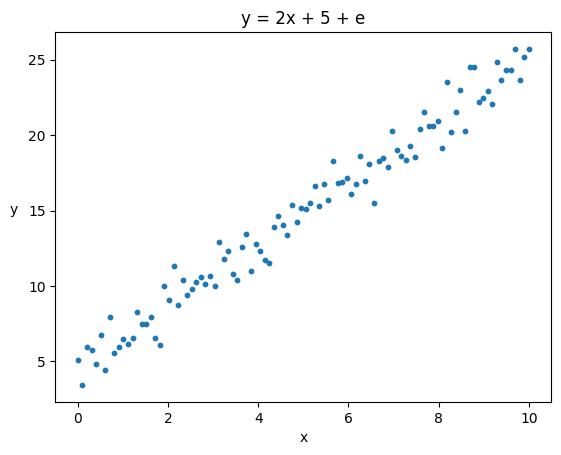

In [251]:
plt.scatter(X, y, s=10)
plt.xlabel('x')
plt.ylabel('y', rotation=0, labelpad=10)
plt.title('y = 2x + 5 + e')

In [252]:
X = X.reshape(-1, 1)
X = np.concatenate([X, np.ones((num_samples,)).reshape(-1, 1)], axis=1)

w = np.zeros((X.shape[1]))

In [253]:
print(X.shape)
print(y.shape)
print(w.shape)

(100, 2)
(100,)
(2,)


In [254]:
from sklearn.metrics import mean_squared_error

def SGD(X, y, w, num_of_epochs = 1000, learning_rate = 0.01):
    w = np.copy(w)
    num_samples = X.shape[0]

    print(mean_squared_error(y, X @ w))

    for epoch in range(num_of_epochs):
        grad = (2 / num_samples) * X.T @ (X @ w - y)
        w = w - learning_rate * grad
    #

    print(mean_squared_error(y, X @ w))
    return w
#

In [257]:
w_est = SGD(X, y, w)
print(f'Estimated weights: {w_est}')

257.6040906228133
1.0681440434767375
Estimated weights: [2.0532762  4.58729186]


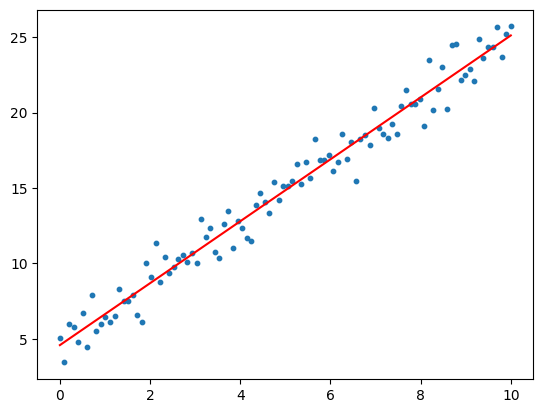

In [256]:
fig, ax = plt.subplots()

ax.scatter(X[:, [0]], y, s=10)

x_est = np.linspace(X[0, 0], X[-1, 0], 100)
y_est = w_est[0] * x_est + w_est[1]

ax.plot(x_est, y_est, c='red')

ax.plot()
plt.show()